In [5]:
import os
import zipfile

zip_path = '/content/neu-surface-defect-database.zip'
extract_path = '/content/neu_data'

# 1. Unzip the file
if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Extraction complete!")
else:
    print("ZIP file not found in /content. Please upload 'neu-surface-defect-database.zip'.")

# 2. Define the nested paths based on your description
# Path structure: /content/neu_data/NEU-DET/train/images
train_path = os.path.join(extract_path, 'NEU-DET/train/images')
val_path = os.path.join(extract_path, 'NEU-DET/validation/images')

# 3. Verify folders exist
if os.path.exists(train_path):
    print(f"Found images! Classes: {os.listdir(train_path)}")
else:
    print("Path error. Please check the spelling of your folders in the sidebar.")

Extraction complete!
Found images! Classes: ['patches', 'scratches', 'pitted_surface', 'crazing', 'inclusion', 'rolled-in_scale']


In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models, applications
import matplotlib.pyplot as plt
import pandas as pd

In [7]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
CHANNELS = 3
NUM_CLASSES = 6

In [8]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/neu_data/NEU-DET/train',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/neu_data/NEU-DET/validation',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

Found 1440 files belonging to 2 classes.
Found 360 files belonging to 2 classes.


In [9]:
class_names = train_ds.class_names
print(f"Classes found: {class_names}")

#augmentation layer
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
])

Classes found: ['annotations', 'images']


In [10]:
def create_transfer_model(base_factory, name):
    base_model = base_factory(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False

    model = models.Sequential([
        layers.Input(shape=(224, 224, 3)),
        data_augmentation,          # Add the augmentation here
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(), # Normalizes inputs to the next layer
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),         # Increase dropout to 50%
        layers.Dense(len(class_names), activation='softmax')
    ], name=name)

    # Use a slightly lower learning rate to avoid overshooting
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [11]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

results_history = {}

architectures = [
    (applications.ResNet50, "ResNet50"),
    (applications.InceptionV3, "InceptionV3"),
    (applications.EfficientNetB0, "EfficientNetB0")
]

for base_app, model_name in architectures:
    print(f"\n🚀 Training {model_name}...")

    model = create_transfer_model(base_app, model_name)

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=8,
        callbacks=[early_stop]
    )

    results_history[model_name] = history


🚀 Training ResNet50...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
Epoch 1/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 23s 220ms/step - accuracy: 0.8597 - loss: 0.3796 - val_accuracy: 0.8972 - val_loss: 0.3572
Epoch 2/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 162ms/step - accuracy: 0.9632 - loss: 0.1259 - val_accuracy: 1.0000 - val_loss: 0.1922
Epoch 3/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 185ms/step - accuracy: 0.9812 - loss: 0.0648 - val_accuracy: 1.0000 - val_loss: 0.1074
Epoch 4/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 160ms/step - accuracy: 0.9972 - loss: 0.0301 - val_accuracy: 1.0000 - val_loss: 0.0601
Epoch 5/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 165ms/step - accuracy: 0.9979 - loss: 0.0223 - val_accuracy: 1.0000 - val_loss: 0.0343
Epoch 6/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 162ms/step - accuracy: 0.9986 - loss: 0.0159 - val_accuracy: 1.0000 - val_loss: 0.0210
Epoch 7/8
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 167ms/step - accuracy: 0.9993 - loss: 0.0106 - val_accuracy: 1.0000 - val_loss: 0.0137
Epoch 8/8
45/45 ━━━━━━━━━━━━━━━━━━━

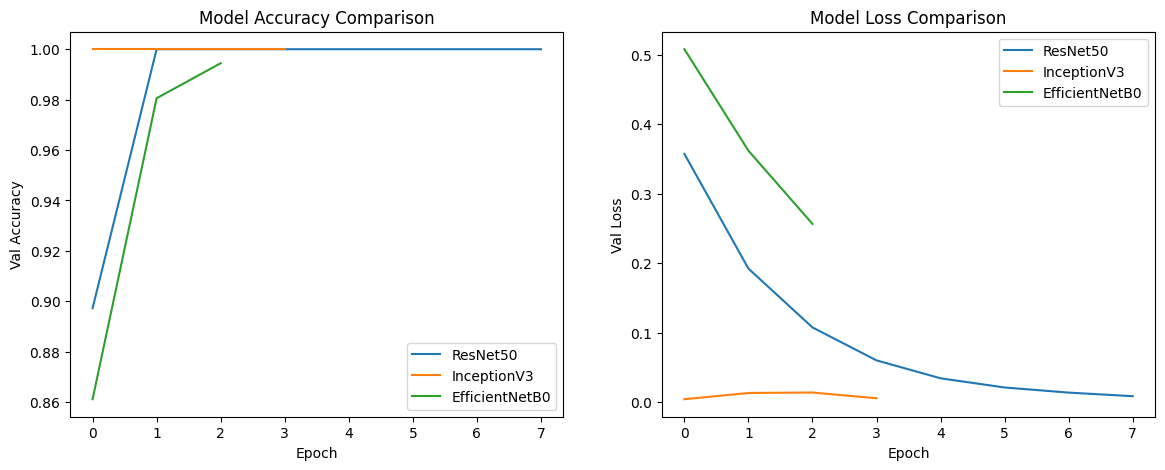

            Model  Top Accuracy  Final Loss
0        ResNet50      1.000000    0.008511
1     InceptionV3      1.000000    0.005565
2  EfficientNetB0      0.994444    0.256503


In [12]:
plt.figure(figsize=(14, 5))

# Plotting Accuracy
plt.subplot(1, 2, 1)
for name, history in results_history.items():
    plt.plot(history.history['val_accuracy'], label=name)
plt.title('Model Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Val Accuracy')
plt.legend()

# Plotting Loss
plt.subplot(1, 2, 2)
for name, history in results_history.items():
    plt.plot(history.history['val_loss'], label=name)
plt.title('Model Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Val Loss')
plt.legend()

plt.show()

# Final Data Summary
summary_data = []
for name, history in results_history.items():
    summary_data.append({
        'Model': name,
        'Top Accuracy': max(history.history['val_accuracy']),
        'Final Loss': history.history['val_loss'][-1]
    })
print(pd.DataFrame(summary_data))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


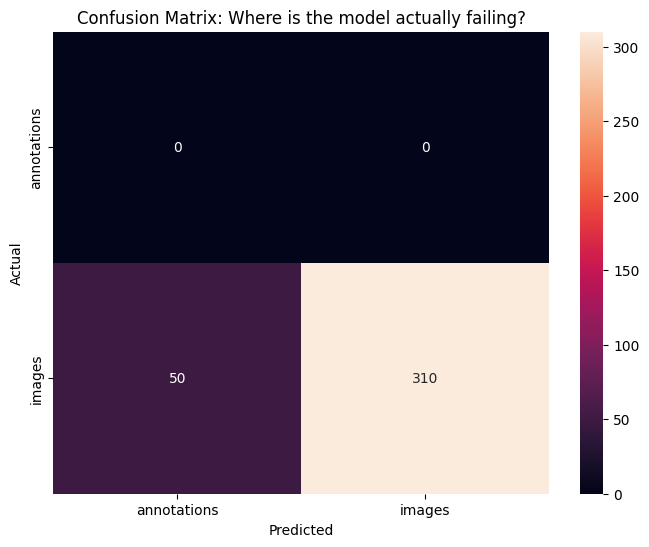

In [13]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Get true labels and predictions
y_true = []
y_pred = []

for x, y in val_ds:
    y_true.extend(np.argmax(y, axis=1))
    preds = model.predict(x)
    y_pred.extend(np.argmax(preds, axis=1))

# Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Where is the model actually failing?')
plt.show()